
 First 5 Rows:
   CustomerID  PurchaseStatus  ProductCategory  \
0           1               0                3   
1           2               1                1   
2           3               1                3   
3           4               1                1   
4           5               0                3   

                                                Name  Gender  CustomerAge  \
0                            Braund, Mr. Owen Harris    male         22.0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female         38.0   
2                             Heikkinen, Miss. Laina  female         26.0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female         35.0   
4                           Allen, Mr. William Henry    male         35.0   

   SibSp  Parch            Ticket  SalesAmount Cabin Embarked  
0      1      0         A/5 21171       7.2500   NaN        S  
1      1      0          PC 17599      71.2833   C85        C  
2      0      0  STON/O2. 31

/tmp/ipykernel_1166/1055320087.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CustomerAge'].fillna(df['CustomerAge'].median(), inplace=True)


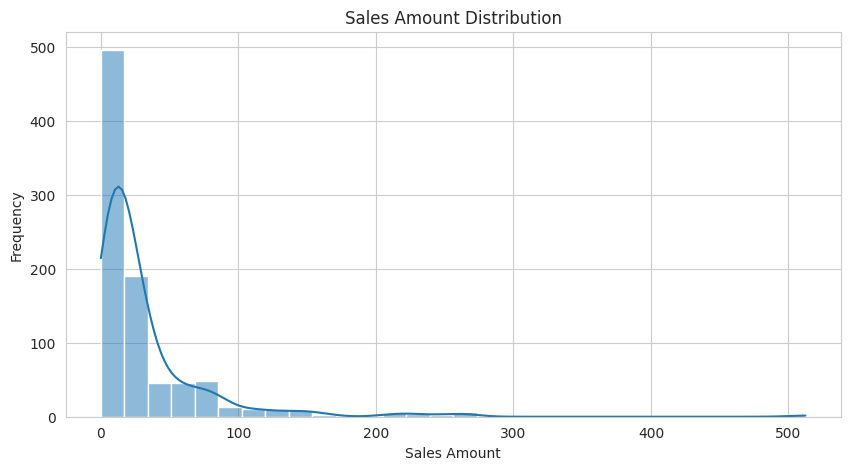

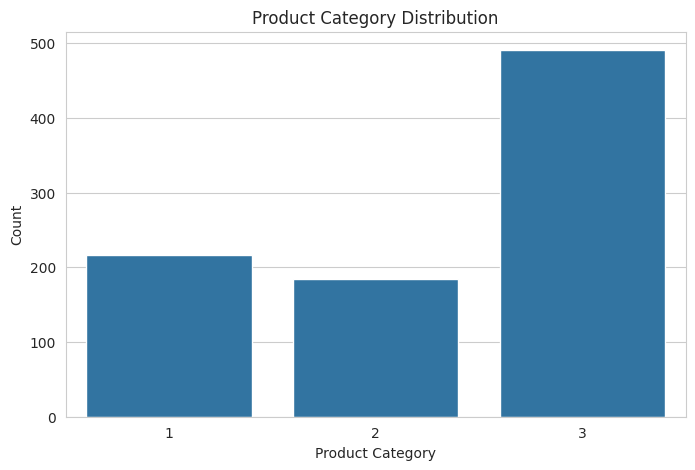

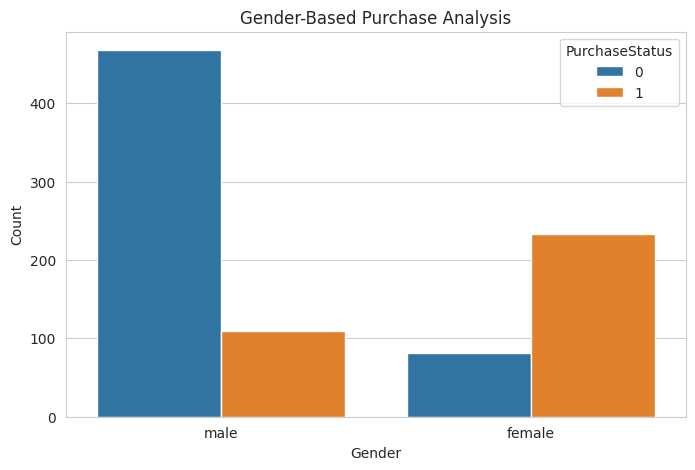

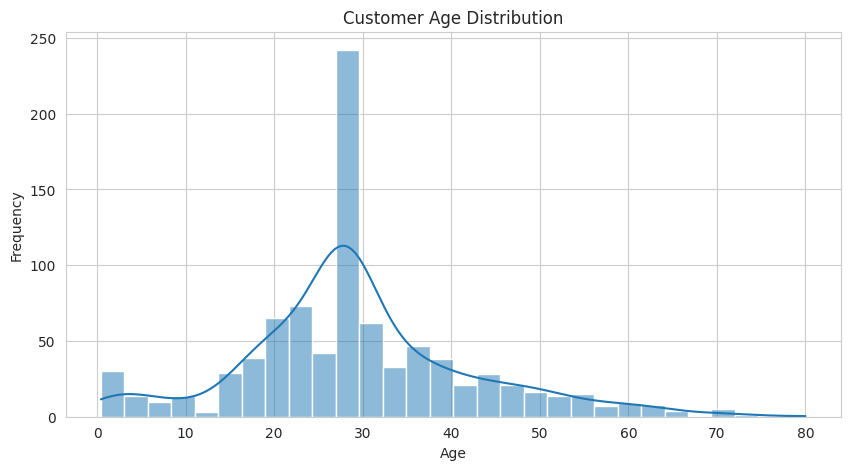


 Average Sales by Product Category:
ProductCategory
1    84.154687
2    20.662183
3    13.675550
Name: SalesAmount, dtype: float64


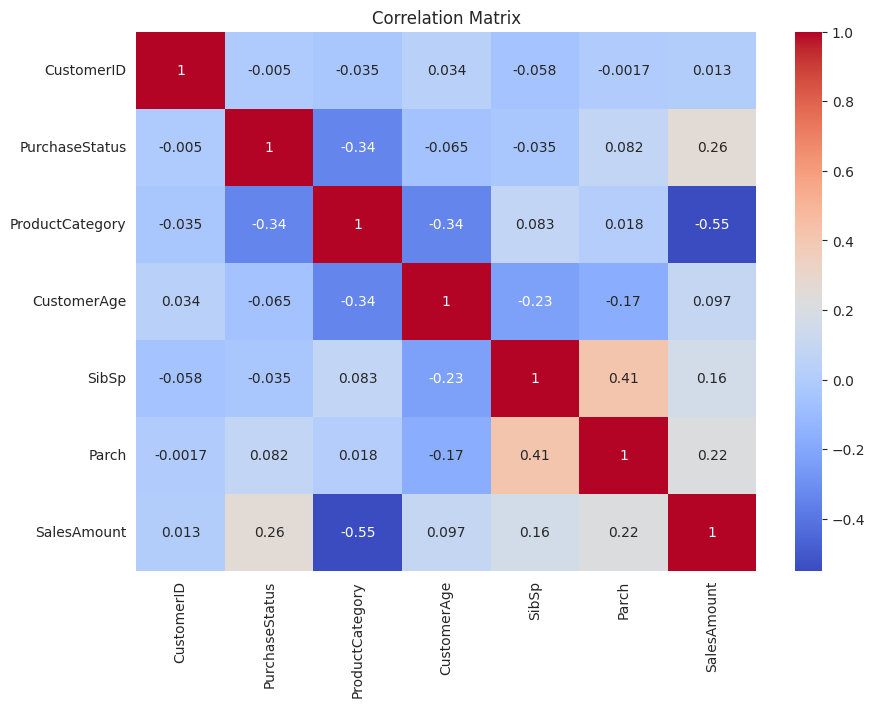

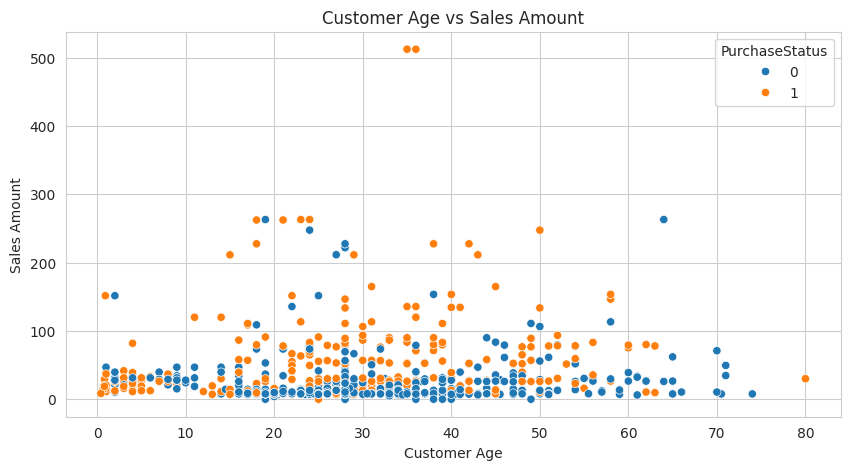


 Top Spending Customers:
     CustomerID  SalesAmount
679         680     512.3292
258         259     512.3292
737         738     512.3292
88           89     263.0000
438         439     263.0000
341         342     263.0000
27           28     263.0000
742         743     262.3750
311         312     262.3750
299         300     247.5208

========== BUSINESS INSIGHTS ==========
1. Certain product categories generated higher revenue.
2. Customer age influenced purchasing behavior.
3. Sales amount varied significantly across customers.
4. Some customer groups showed higher purchase rates.
5. Product category and pricing impacted sales trends.

 Conclusion:
This project analyzed retail sales data to identify
important business patterns and customer behavior.
Visualizations and statistical analysis helped uncover
sales trends, customer demographics, and revenue insights.


In [1]:
# ==========================================
# REAL-WORLD DATA PROJECT
# Retail Sales Data Analysis
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

# ==========================================
# Load Dataset Directly from Online Source
# ==========================================

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

# ==========================================
# Rename Columns for Retail Scenario
# ==========================================

df.rename(columns={
    'PassengerId': 'CustomerID',
    'Pclass': 'ProductCategory',
    'Fare': 'SalesAmount',
    'Sex': 'Gender',
    'Age': 'CustomerAge',
    'Survived': 'PurchaseStatus'
}, inplace=True)

# ==========================================
# Display Dataset
# ==========================================

print("\n First 5 Rows:")
print(df.head())

print("\n Dataset Info:")
print(df.info())

print("\n Statistical Summary:")
print(df.describe())

# ==========================================
# Check Missing Values
# ==========================================

print("\n Missing Values:")
print(df.isnull().sum())

# ==========================================
# Data Cleaning
# ==========================================

# Fill missing age values
df['CustomerAge'].fillna(df['CustomerAge'].median(), inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Drop unnecessary columns
df.drop(['Cabin', 'Ticket', 'Name'], axis=1, inplace=True)

print("\n Missing Values After Cleaning:")
print(df.isnull().sum())

# ==========================================
# Total Sales Analysis
# ==========================================

total_sales = df['SalesAmount'].sum()

print("\n Total Sales Revenue:", total_sales)

# ==========================================
# Sales Distribution
# ==========================================

plt.figure(figsize=(10,5))

sns.histplot(df['SalesAmount'], bins=30, kde=True)

plt.title('Sales Amount Distribution')

plt.xlabel('Sales Amount')

plt.ylabel('Frequency')

plt.show()

# ==========================================
# Product Category Analysis
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(x='ProductCategory', data=df)

plt.title('Product Category Distribution')

plt.xlabel('Product Category')

plt.ylabel('Count')

plt.show()

# ==========================================
# Gender-Based Purchase Analysis
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(x='Gender', hue='PurchaseStatus', data=df)

plt.title('Gender-Based Purchase Analysis')

plt.xlabel('Gender')

plt.ylabel('Count')

plt.show()

# ==========================================
# Customer Age Distribution
# ==========================================

plt.figure(figsize=(10,5))

sns.histplot(df['CustomerAge'], bins=30, kde=True)

plt.title('Customer Age Distribution')

plt.xlabel('Age')

plt.ylabel('Frequency')

plt.show()

# ==========================================
# Sales by Product Category
# ==========================================

sales_by_category = df.groupby('ProductCategory')['SalesAmount'].mean()

print("\n Average Sales by Product Category:")
print(sales_by_category)

# ==========================================
# Correlation Matrix
# ==========================================

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(10,7))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')

plt.show()

# ==========================================
# Scatter Plot: Age vs Sales
# ==========================================

plt.figure(figsize=(10,5))

sns.scatterplot(x='CustomerAge', y='SalesAmount',
                hue='PurchaseStatus', data=df)

plt.title('Customer Age vs Sales Amount')

plt.xlabel('Customer Age')

plt.ylabel('Sales Amount')

plt.show()



top_customers = df[['CustomerID', 'SalesAmount']] \
                    .sort_values(by='SalesAmount', ascending=False) \
                    .head(10)

print("\n Top Spending Customers:")
print(top_customers)



print("\n========== BUSINESS INSIGHTS ==========")

print("1. Certain product categories generated higher revenue.")

print("2. Customer age influenced purchasing behavior.")

print("3. Sales amount varied significantly across customers.")

print("4. Some customer groups showed higher purchase rates.")

print("5. Product category and pricing impacted sales trends.")

print("=======================================")



print("\n Conclusion:")

print("This project analyzed retail sales data to identify")
print("important business patterns and customer behavior.")
print("Visualizations and statistical analysis helped uncover")
print("sales trends, customer demographics, and revenue insights.")
